[nan]
[   0.  400. 3000. 1500. 1600. 3800. 1620. 4200. 1700.  900. 1950. 2700.
  850. 1560. 1250. 2740. 2900. 2400. 2180. 1550. 2974.]
       VMA/B      Tf(MPa)
count    0.0   308.000000
mean     NaN  1310.538961
std      NaN  1135.844467
min      NaN     0.000000
25%      NaN   400.000000
50%      NaN  1560.000000
75%      NaN  1620.000000
max      NaN  4200.000000


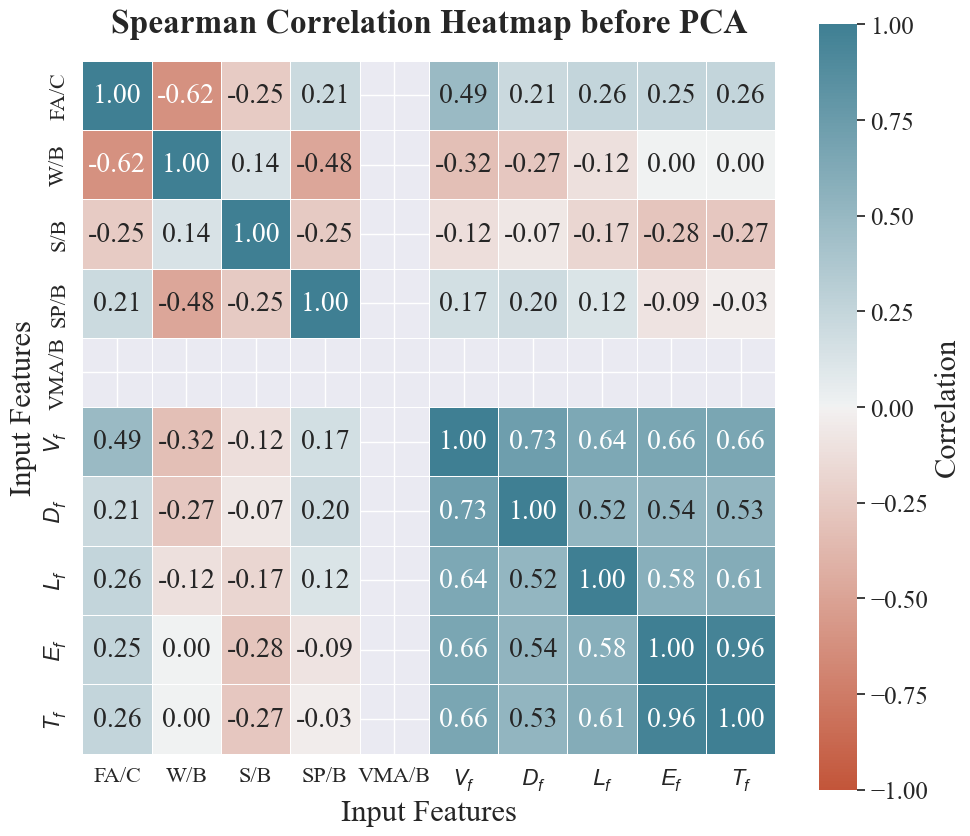

Saved high-quality heatmap as 'feature_selection/Spearman_Correlation_Heatmap_before_PCA.jpg'


In [5]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

np.random.seed(33)
xls = pd.ExcelFile('utils/Database.xlsx')
data = pd.read_excel(xls, 'Sheet1')
OUTPUT_DIR = 'feature_selection'
os.makedirs(OUTPUT_DIR, exist_ok=True)

x_cols = ['FA/C', 'W/B', 'S/B', 'SP/B', 'VMA/B', 'Vf(%)', 'Df(um)', 'Lf(mm)', 'Ef(GPa)', 'Tf(MPa)']
x_labels = ['FA/C', 'W/B', 'S/B', 'SP/B', 'VMA/B', '$V_f$', '$D_f$', '$L_f$', '$E_f$', '$T_f$']
df = pd.DataFrame(data, columns=x_cols)
df = df.astype(float)

print(df['VMA/B'].unique())  # 查看VMA/B列的唯一值
print(df['Tf(MPa)'].unique())  # 查看Tf列的唯一值
print(df[['VMA/B', 'Tf(MPa)']].describe())  # 查看这两列的统计描述

correlation, p_values = spearmanr(df)
corr_df = pd.DataFrame(correlation, columns=x_labels, index=x_labels)

# 创建图形并设置全局字体缩放
plt.figure(figsize=(10, 10))
sns.set_theme(font='Times New Roman')
sns.set_palette("coolwarm")
sns.set(font_scale=1.2)  # 全局字体缩放系数

mask = np.zeros_like(corr_df, dtype=bool)
cmap = sns.diverging_palette(20, 220, as_cmap=True)

plt.rcParams['font.family'] = 'serif'  
plt.rcParams['font.serif'] = ['Times New Roman']  
plt.rcParams['mathtext.fontset'] = 'custom'  
plt.rcParams['mathtext.rm'] = 'Times New Roman'

# 绘制热力图并可单独调整各部分字体
ax = sns.heatmap(
    corr_df, 
    mask=mask, 
    cmap=cmap, 
    annot=True, 
    fmt=".2f", 
    linewidths=.5, 
    cbar=True, 
    cbar_kws={
        "shrink": .8,
        "label": "Correlation"  # 添加颜色条标签
    }, 
    square=True, 
    center=0, 
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 20}  # 注释数字的字体大小
)

# 设置标题和轴标签字体大小

plt.title('Spearman Correlation Heatmap before PCA',fontdict={'family': 'Times New Roman', 'weight': 'bold', 'size': 24}, pad=20)
plt.xlabel('Input Features',  fontdict={'family': 'Times New Roman', 'size': 22})
plt.ylabel('Input Features',  fontdict={'family': 'Times New Roman', 'size': 22})

# 单独调整坐标轴标签的字号
ax.tick_params(axis='both', which='major', labelsize=16)  # x和y轴刻度标签
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Correlation", fontfamily='Times New Roman', fontsize=22)
cbar.ax.tick_params(labelsize=18)  # 颜色条刻度字体大小

output_path = OUTPUT_DIR + '/Spearman_Correlation_Heatmap_before_PCA.jpg'
plt.tight_layout()  # 防止标签被截断
plt.savefig(output_path, format='jpg', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved high-quality heatmap as '{output_path}'")

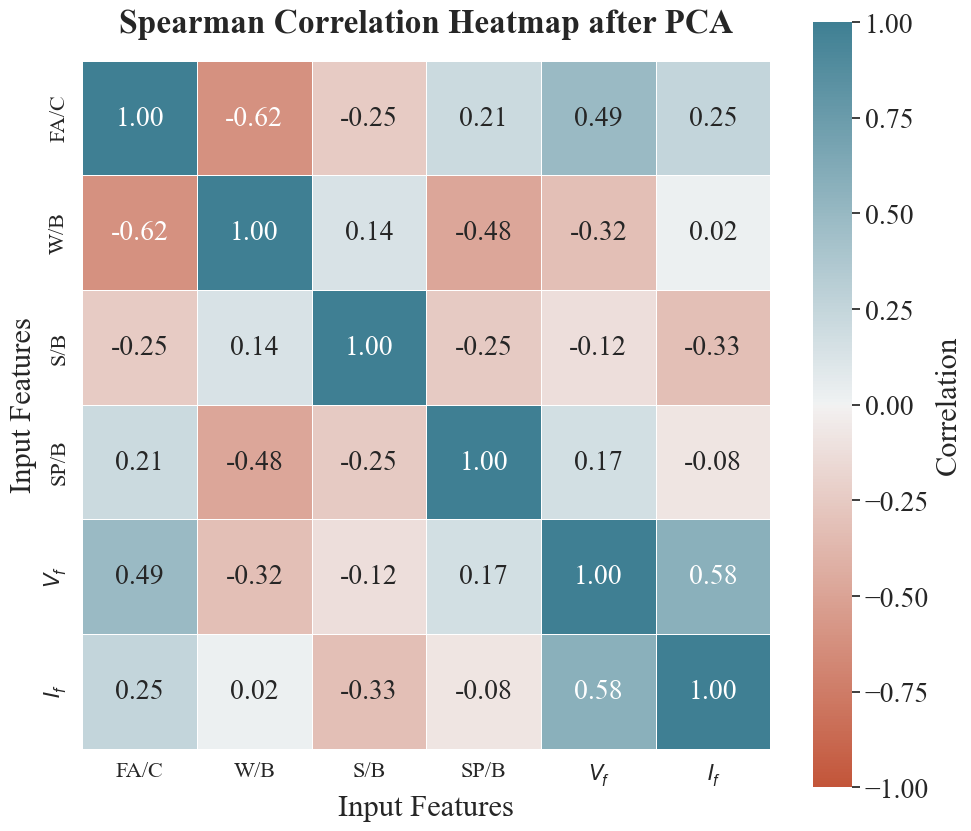

Saved high-quality heatmap as 'feature_selection/Spearman_Correlation_Heatmap_after_PCA.jpg'


In [6]:
xls2 = pd.ExcelFile('utils/Database.xlsx')
data_2 = pd.read_excel(xls2, 'Sheet1')

x_cols_2 = ['FA/C', 'W/B', 'S/B', 'SP/B', 'Vf(%)', 'If']
x_labels_2 = ['FA/C', 'W/B', 'S/B', 'SP/B', '$V_f$', '$I_f$']

df_2 = pd.DataFrame(data_2, columns=x_cols_2)
df_2 = df_2.astype(float)

correlation_2, p_values_2 = spearmanr(df_2)
corr_df_2 = pd.DataFrame(correlation_2, columns=x_labels_2, index=x_labels_2)

# 创建图形并设置全局字体缩放
plt.figure(figsize=(10, 10))
sns.set_theme(font='Times New Roman')
sns.set_palette("coolwarm")
sns.set(font_scale=1.2)  # 全局字体缩放系数

mask_2 = np.zeros_like(corr_df_2, dtype=bool)
cmap_2 = sns.diverging_palette(20, 220, as_cmap=True)

plt.rcParams['font.family'] = 'serif'  
plt.rcParams['font.serif'] = ['Times New Roman']  
plt.rcParams['mathtext.fontset'] = 'custom'  
plt.rcParams['mathtext.rm'] = 'Times New Roman'

# 绘制热力图并可单独调整各部分字体
ax = sns.heatmap(
    corr_df_2, 
    mask=mask_2, 
    cmap=cmap_2, 
    annot=True, 
    fmt=".2f", 
    linewidths=.5, 
    cbar=True, 
    cbar_kws={
        "shrink": .8,
        "label": "Correlation"  # 添加颜色条标签
    }, 
    square=True, 
    center=0, 
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 20}  # 注释数字的字体大小
)

# 设置标题和轴标签字体大小

plt.title('Spearman Correlation Heatmap after PCA',fontdict={'family': 'Times New Roman', 'weight': 'bold', 'size': 24}, pad=20)
plt.xlabel('Input Features',  fontdict={'family': 'Times New Roman', 'size': 22})
plt.ylabel('Input Features',  fontdict={'family': 'Times New Roman', 'size': 22})

# 单独调整坐标轴标签的字号
ax.tick_params(axis='both', which='major', labelsize=16)  # x和y轴刻度标签
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Correlation", fontfamily='Times New Roman', fontsize=22)
cbar.ax.tick_params(labelsize=20)  # 颜色条刻度字体大小

output_path_2 = OUTPUT_DIR + '/Spearman_Correlation_Heatmap_after_PCA.jpg'
plt.tight_layout()  # 防止标签被截断
plt.savefig(output_path_2, format='jpg', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved high-quality heatmap as '{output_path_2}'")


C:\Users\admin\AppData\Local\Temp\ipykernel_11964\812320282.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.0, h_pad=1.0, w_pad=1.0)  # 调整整体边距和子图间距


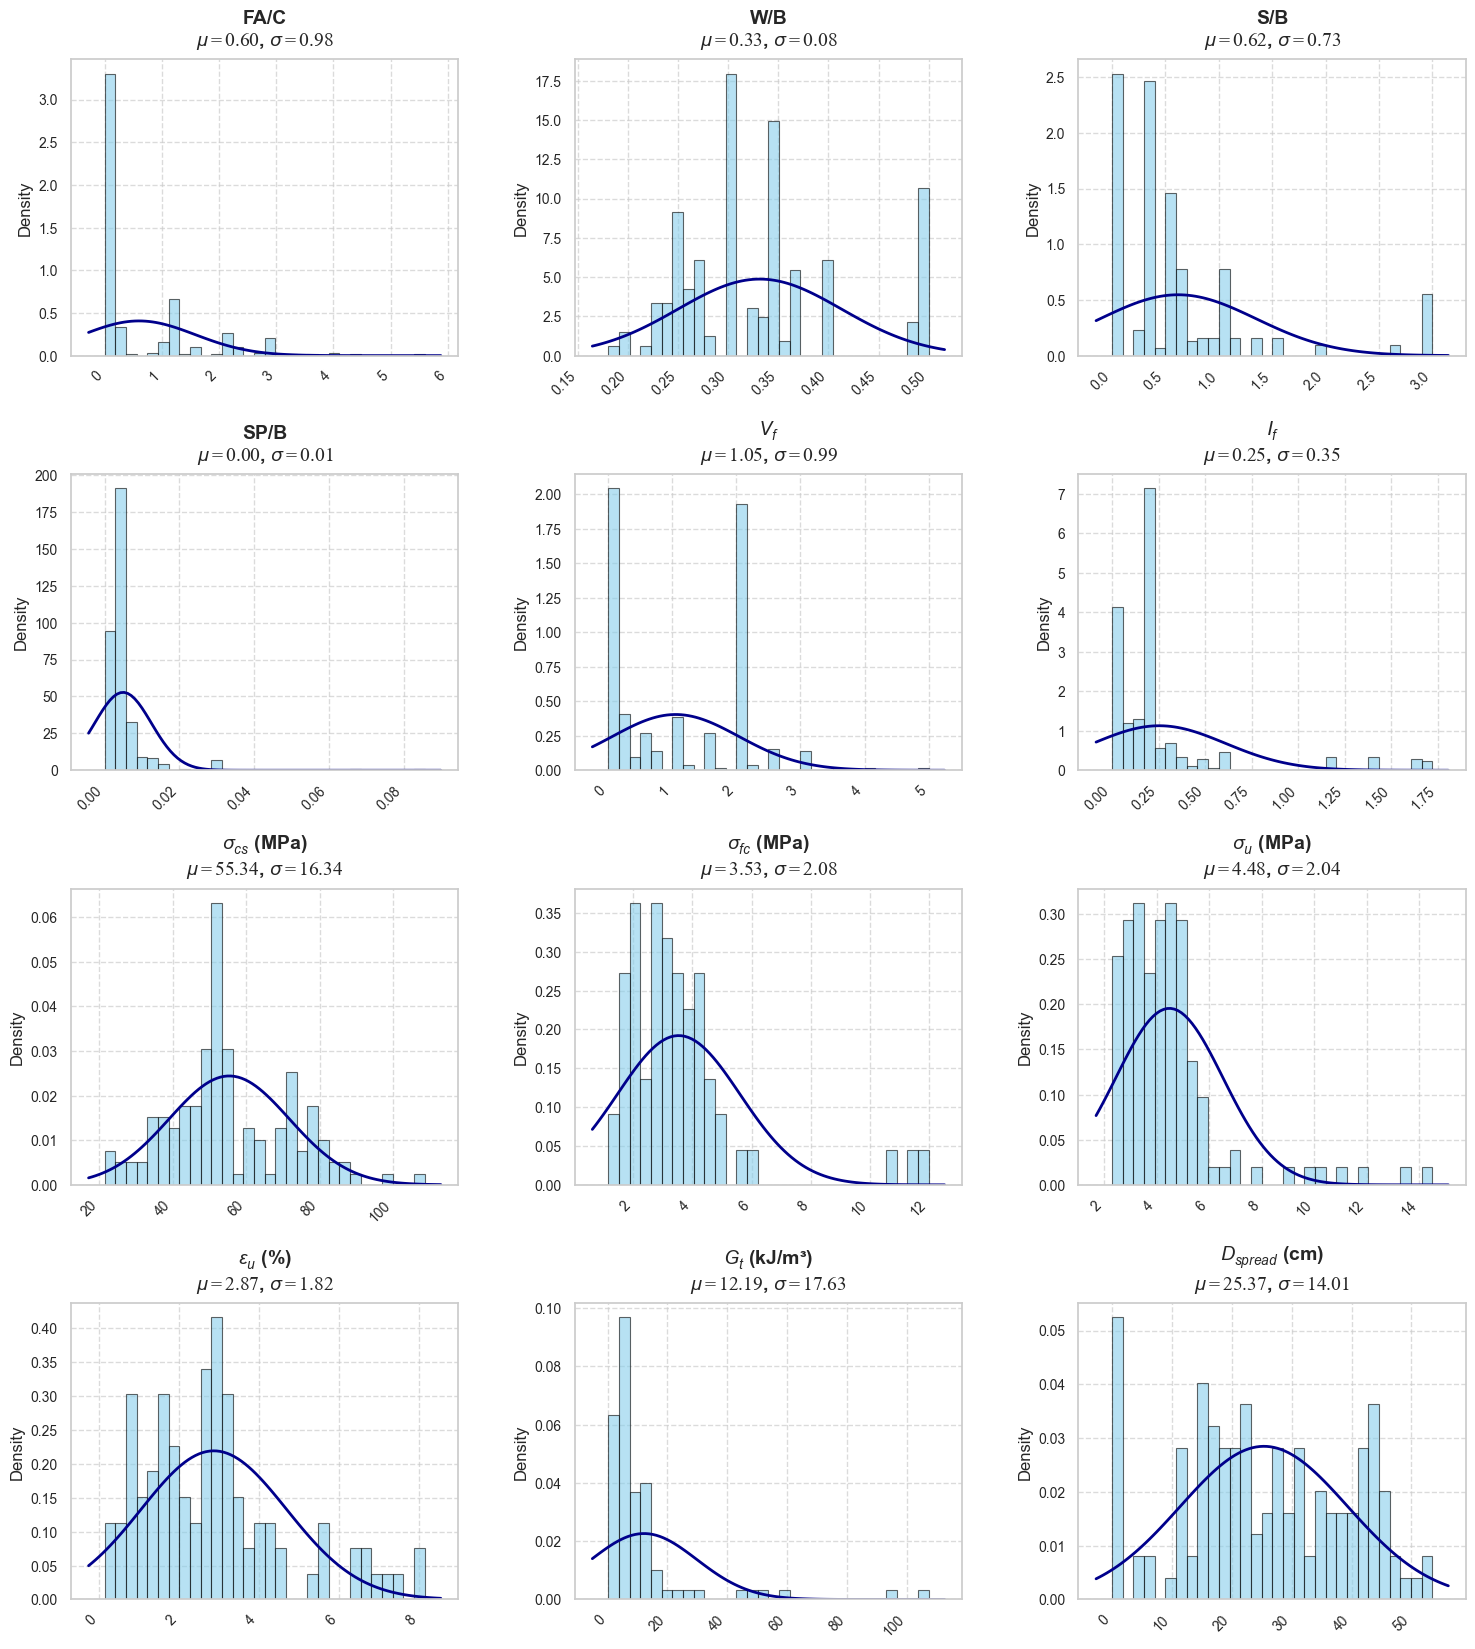

Saved combined distribution plot to feature_selection\all_features_distribution.jpg

Statistical Summaries:
FA/C       | Mean: 0.6013 | Std: 0.9814
W/B        | Mean: 0.3313 | Std: 0.0819
S/B        | Mean: 0.6187 | Std: 0.7301
SP/B       | Mean: 0.0049 | Std: 0.0076
$V_f$      | Mean: 1.0506 | Std: 0.9870
$I_f$      | Mean: 0.2533 | Std: 0.3543
$\sigma_{cs}$ (MPa) | Mean: 55.3424 | Std: 16.3385
$\sigma_{fc}$ (MPa) | Mean: 3.5330 | Std: 2.0764
$\sigma_{u}$ (MPa) | Mean: 4.4813 | Std: 2.0401
$\varepsilon_{u}$ (%) | Mean: 2.8749 | Std: 1.8184
$G_t$ (kJ/m³) | Mean: 12.1891 | Std: 17.6282
$D_{spread}$ (cm) | Mean: 25.3685 | Std: 14.0093


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
from matplotlib.gridspec import GridSpec

# 加载数据
xls2 = pd.ExcelFile('utils/Database.xlsx')
data_2 = pd.read_excel(xls2, 'Sheet1')

# 定义变量
x_cols = ['FA/C', 'W/B', 'S/B', 'SP/B', 'Vf(%)', 'If', 'CX(MPa)', 'FCX(MPa)', 'UTX(Mpa)', 'UTS(%)', 'G(KJm3)', 'MiniSF(cm)']
x_labels = ['FA/C', 'W/B', 'S/B', 'SP/B', '$V_f$', '$I_f$', '$\sigma_{cs}$ (MPa)', '$\sigma_{fc}$ (MPa)', '$\sigma_{u}$ (MPa)', '$\\varepsilon_{u}$ (%)', '$G_t$ (kJ/m³)', '$D_{spread}$ (cm)']
x_col_label_mapping = dict(zip(x_cols, x_labels))

# 数据预处理
df_2 = pd.DataFrame(data_2, columns=x_cols)
df_2 = df_2.astype(float)

# 设置Seaborn样式
sns.set_style("whitegrid")
sns.set_palette("husl")

# 创建3×3的大图，调整间距参数
fig = plt.figure(figsize=(18, 20))
gs = GridSpec(4, 3, figure=fig, wspace=0.3, hspace=0.4)  # 减小子图间距

for i, feature in enumerate(x_cols):
    ax = fig.add_subplot(gs[i])
    feature_column = df_2[feature].dropna()
    
    # 计算统计量
    mean_feature = np.mean(feature_column)
    std_feature = np.std(feature_column)
    
    # 绘制直方图
    count, bins, _ = ax.hist(feature_column, bins=30, density=True, 
                            alpha=0.6, color='skyblue', 
                            edgecolor='black', linewidth=0.8)
    
    # 绘制正态分布曲线
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mean_feature, std_feature)
    ax.plot(x, p, 'darkblue', linewidth=2)
    
    # 美化图形，调整字体大小和标题位置
    ax.set_title(f"{x_col_label_mapping[feature]}\n$\mu={mean_feature:.2f}$, $\sigma={std_feature:.2f}$", 
                fontsize=14, pad=10, weight='bold')  # 减小字体大小和增加标题与图的间距
    ax.set_xlabel('', fontsize=12)  # 减小字体大小
    ax.set_ylabel('Density', fontsize=12)  # 减小字体大小
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='both', labelsize=10)  # 减小tick标签大小
    
    # 旋转x轴标签防止重叠
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 更紧凑的布局调整
plt.tight_layout(pad=1.0, h_pad=1.0, w_pad=1.0)  # 调整整体边距和子图间距

# 保存图像
os.makedirs(OUTPUT_DIR, exist_ok=True)
output_path = os.path.join(OUTPUT_DIR, "all_features_distribution.jpg")
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()

print(f"Saved combined distribution plot to {output_path}")

# 控制台输出统计信息
print("\nStatistical Summaries:")
for feature in x_cols:
    feature_column = df_2[feature].dropna()
    mean_feature = np.mean(feature_column)
    std_feature = np.std(feature_column)
    print(f"{x_col_label_mapping[feature]:<10} | Mean: {mean_feature:.4f} | Std: {std_feature:.4f}")
